# The Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/facebook/prophet/main/examples/example_air_passengers.csv"
data = pd.read_csv(url, header = 0, parse_dates = [0], index_col = 0)
train = data.iloc[:-12]
test = data.iloc[-12:]

data

,y
ds,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


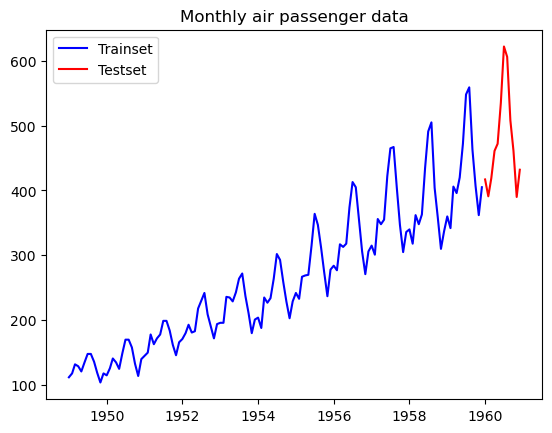

In [2]:
fig = plt.figure()
ax = fig.add_subplot()
ax.plot(train.index, train.y, color = "blue", label = "Trainset")
ax.plot(test.index, test.y, color = "red", label = "Testset")
ax.legend()
ax.set_title("Monthly air passenger data")
plt.show()

# Statistical Methods

## (Partial-) AutcoCorrelation

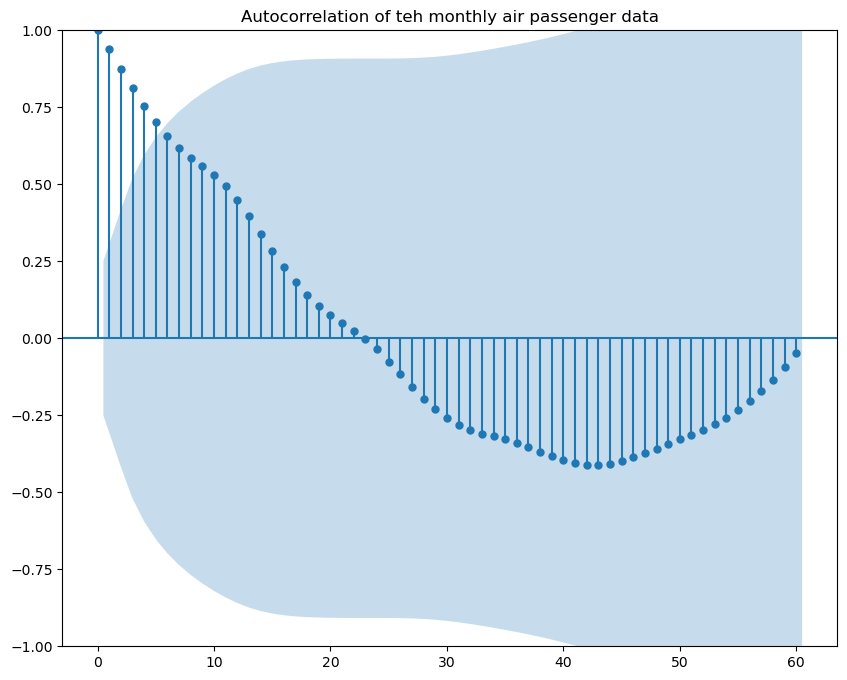

In [3]:
from statsmodels.tsa.stattools import acf

monthly_acf = acf(train, nlags=60)# , qstat=True, fft=True, alpha=0.05, bartlett_confint=True, missing='none')

from statsmodels.graphics.tsaplots import plot_acf
fig = plt.figure(figsize = (10, 8))

ax = fig.add_subplot()
plot_acf(
    monthly_acf,
    ax = ax,
    alpha = 0.05,
    lags = len(monthly_acf) - 1
)
ax.set_xticks(ticks = [i for i in range(0, len(monthly_acf), 10)])
ax.set_title("Autocorrelation of teh monthly air passenger data")
plt.show()

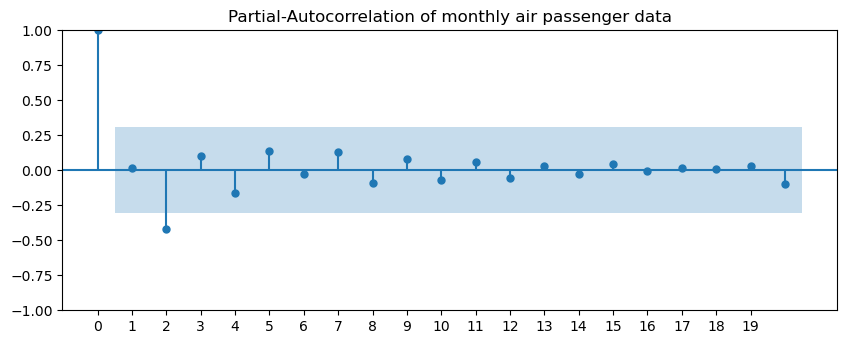

In [4]:
from statsmodels.tsa.stattools import pacf
monthly_pacf = pacf(train, nlags=40)# , qstat=True, fft=True, alpha=0.05, bartlett_confint=True, missing='none')

from statsmodels.graphics.tsaplots import plot_pacf
fig = plt.figure(figsize = (10, 8))

ax = fig.add_subplot(2, 1, 1)
plot_pacf(
    monthly_pacf,
    ax = ax,
    alpha = 0.05,
    lags = (len(monthly_pacf) - 1)//2
)
ax.set_xticks(ticks = [i for i in range(0, len(monthly_pacf)//2)])
ax.set_title("Partial-Autocorrelation of monthly air passenger data")

plt.show()

### Evaluation
1. ACF: Autocorrelation decays over time. Hints at seasonal pattern in the data
2. ACF: Only months close to one another (up to a lag of 5) haev significant autocorrelation. Hints at a trend in the data
3. PCAF: The only significant non-zero lag is at lag 2. This is therefore deemed the appropriate lag for future analysis

In [5]:
res_dict = {}
def add_to_resdict(name, y_pred, res_dict):
    res_dict[name] = {}
    mse = mean_squared_error(y_pred, test)
    mae = mean_absolute_error(y_pred, test)
    res_dict[name]["mse"] = mse
    res_dict[name]["mae"] = mae
    return res_dict

## Autoregressive Model

In [6]:
from statsmodels.tsa.ar_model import AutoReg# , ar_select_order
model = AutoReg(train, lags = 40, trend = "c")
res = model.fit()

C:\Users\flash\anaconda3\envs\ML_Pytorch\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [7]:
print(res.summary())

                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:                  132
Model:                    AutoReg(40)   Log Likelihood                -316.343
Method:               Conditional MLE   S.D. of innovations              7.535
Date:                Fri, 12 Jun 2026   AIC                            716.687
Time:                        20:34:42   BIC                            822.602
Sample:                    05-01-1952   HQIC                           759.435
                         - 12-01-1959                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.1772      4.030      1.781      0.075      -0.721      15.075
y.L1           0.6512      0.109      5.968      0.000       0.437       0.865
y.L2           0.2388      0.128      1.863      0.0

### Observations
1. Similar to the ACF Plot, we se that the first few lags are significant and few of the greater lags
2. Among the greater lags, the lag of 12, 23 (almost 24) and 38 (almost 36) are significant, suggesting a yearly pattern

C:\Users\flash\anaconda3\envs\ML_Pytorch\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


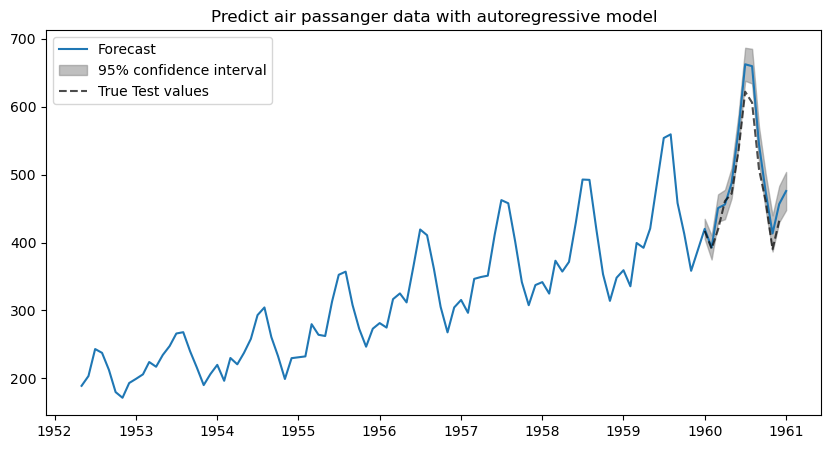

In [8]:
fig = res.plot_predict(start = 0, end = 144, figsize = (10, 5))
ax = fig.get_axes()[0]
ax.plot(test, label = "True Test values", color = "black", linestyle = "--", alpha = 0.7)
ax.legend()
ax.set_title("Predict air passanger data with autoregressive model")
plt.show()

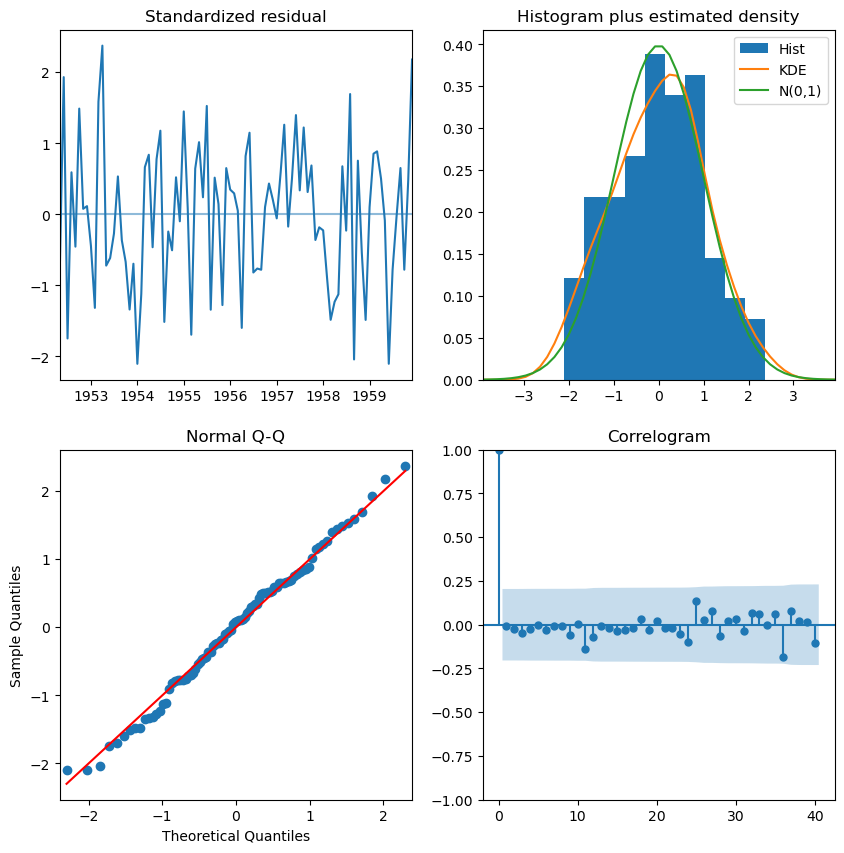

In [9]:
fig = plt.figure(figsize = (10, 10))
res.plot_diagnostics(fig=fig, lags=40)
plt.show()

### Observations
1. The Histogram and Q-Q plot show us that the residual error of the datafit is roughly normal distributed. Therefore, we can trust the predictions of the data // Therefore, the AR model is sufficient in capturing the data.

In [10]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
res_dict = add_to_resdict("AR", res.predict(133, 144), res_dict)

C:\Users\flash\anaconda3\envs\ML_Pytorch\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


## ARIMA

### Addfuller (Test of Stationarity)

In [11]:
from statsmodels.tsa.stattools import adfuller
alpha = 0.05
result = adfuller(train)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
if result[1] < alpha:
    print("Data is stationary")
else:
    print("Data is not-stationary")

ADF Statistic: 0.888027
p-value: 0.992932
Data is not-stationary


Derivative 1 is not-stationary
Derivative 2 is not-stationary
Derivative 3 is not-stationary
Derivative 4 is not-stationary
Derivative 5 is not-stationary
Derivative 6 is not-stationary

ADF Statistic: -3.488543
p-value: 0.008286
Data is stationary


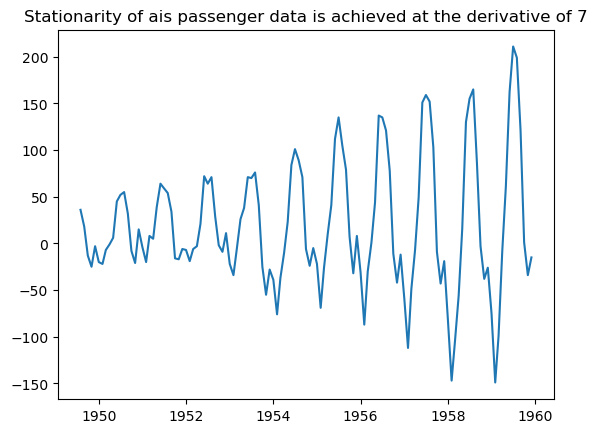

In [12]:
dfff = train.copy()
for i in range(1, 13):
    diff = train.diff(i).dropna()
    result = adfuller(diff)
    
    if result[1] < alpha:
        print()
        print('ADF Statistic: %f' % result[0])
        print('p-value: %f' % result[1])
        print("Data is stationary")
        fig = plt.figure()
        ax = fig.add_subplot()
        ax.plot(diff)
        ax.set_title(f"Stationarity of ais passenger data is achieved at the derivative of {i}")
        plt.show()
        break
    else:
        print(f"Derivative {i} is not-stationary")

### (P)ACF

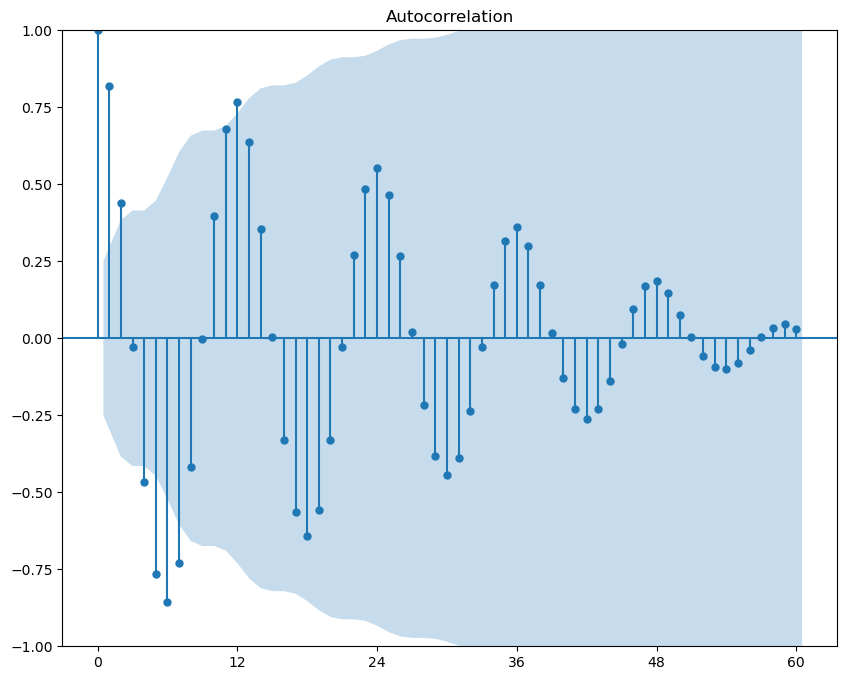

In [13]:
monthly_acf = acf(diff, nlags=60)# , qstat=True, fft=True, alpha=0.05, bartlett_confint=True, missing='none')

from statsmodels.graphics.tsaplots import plot_acf
fig = plt.figure(figsize = (10, 8))

ax = fig.add_subplot()
plot_acf(
    monthly_acf,
    ax = ax,
    alpha = 0.05,
    lags = len(monthly_acf) - 1
)
ax.set_xticks(ticks = [i for i in range(0, len(monthly_acf), 12)])
ax.set_title("Autocorrelation")
plt.show()

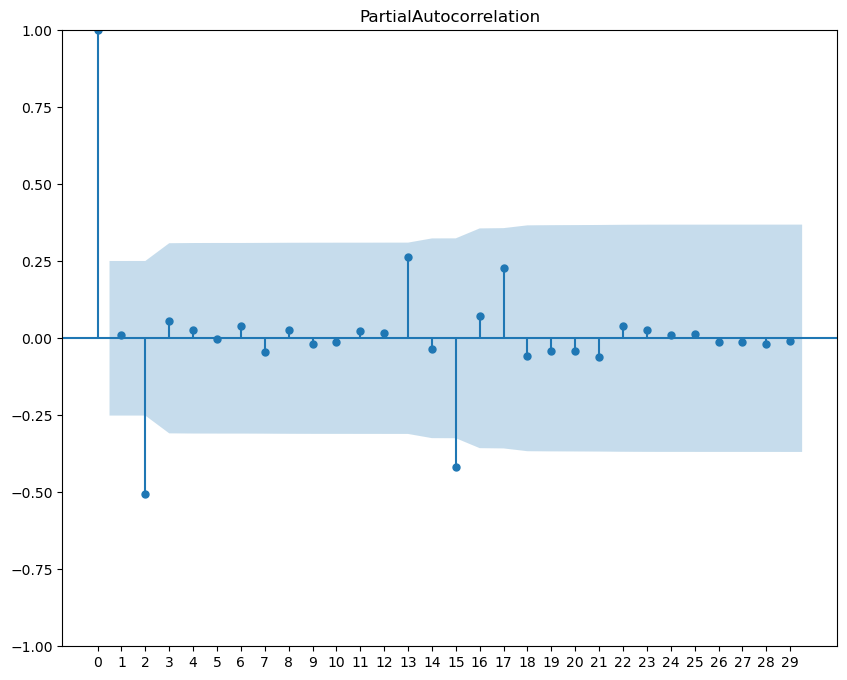

In [14]:
monthly_acf = pacf(train, nlags=60)# , qstat=True, fft=True, alpha=0.05, bartlett_confint=True, missing='none')

from statsmodels.graphics.tsaplots import plot_acf
fig = plt.figure(figsize = (10, 8))

ax = fig.add_subplot()
plot_acf(
    monthly_acf,
    ax = ax,
    alpha = 0.05,
    lags = len(monthly_acf)//2 - 1
)
ax.set_xticks(ticks = [i for i in range(0, len(monthly_acf)//2)])
ax.set_title("PartialAutocorrelation")
plt.show()

In [15]:
from statsmodels.tsa.arima.model import ARIMA

p = 2 # How many lags are we involving for the autoregression part? (Dependence on previous values)
d = 1 # What Derivative are we using?
q = 5 # How many lags for the moving average part? (Dependance on previous forecast error)

arima_model = ARIMA(train, order = (p, d, q))
arima_result = arima_model.fit()
arima_forecast = arima_result.forecast(steps = len(test))

C:\Users\flash\anaconda3\envs\ML_Pytorch\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\flash\anaconda3\envs\ML_Pytorch\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\flash\anaconda3\envs\ML_Pytorch\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\flash\anaconda3\envs\ML_Pytorch\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


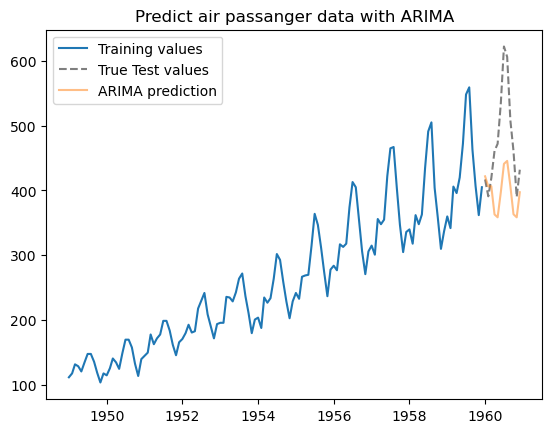

In [16]:
fig = plt.figure()
ax = fig.add_subplot()
ax.plot(train, label = "Training values")
ax.plot(test, label = "True Test values", color = "black", linestyle = "--", alpha = 0.5)
ax.plot(arima_forecast, label = "ARIMA prediction", alpha = 0.5)
ax.legend()
ax.set_title("Predict air passanger data with ARIMA")
plt.show()

In [17]:
res_dict = add_to_resdict("ARIMA", arima_forecast, res_dict)

## SARIMAX

### Seasonal Trend Decomposition

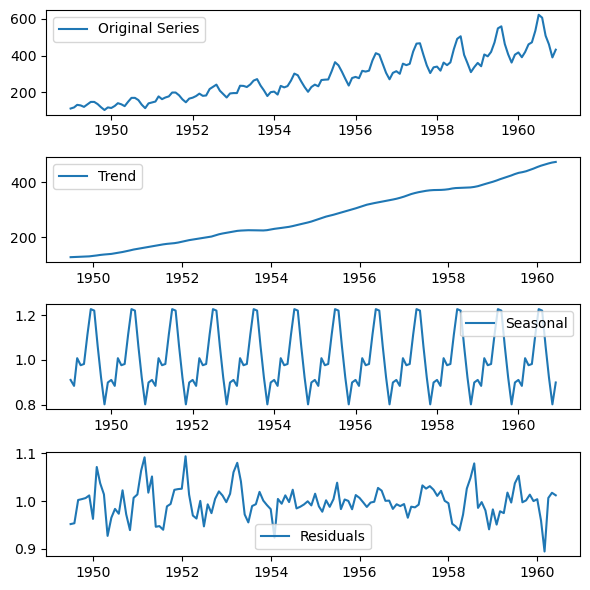

In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(data, model='multiplicativ', period=12)
trend = result.trend.dropna()
seasonal = result.seasonal.dropna()
residual = result.resid.dropna()

# Plot the decomposed components
plt.figure(figsize=(6,6))

plt.subplot(4, 1, 1)
plt.plot(data, label='Original Series')
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(trend, label='Trend')
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(seasonal, label='Seasonal')
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(residual, label='Residuals')
plt.legend()

plt.tight_layout()
plt.show()

In [19]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

p = 2
d = 2
q = 5

P = 1
D = 1
Q = 1
s = 12

sarimax_model = SARIMAX(endog = train, order = (p, d, q), seasonal_order = (P, D, Q, s))
sarimax_result = sarimax_model.fit()
sarimax_forecast = sarimax_result.forecast(steps = len(test))

C:\Users\flash\anaconda3\envs\ML_Pytorch\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\flash\anaconda3\envs\ML_Pytorch\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\flash\anaconda3\envs\ML_Pytorch\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\flash\anaconda3\envs\ML_Pytorch\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


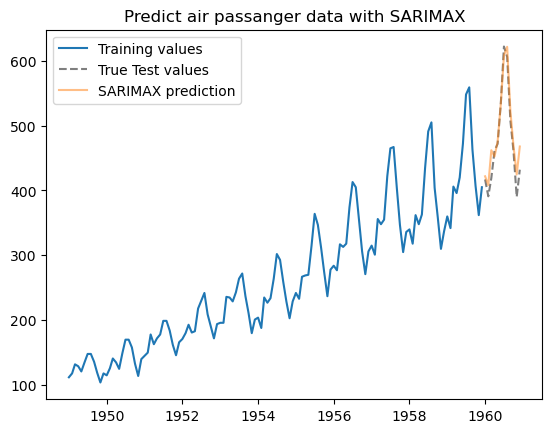

In [20]:
fig = plt.figure()
ax = fig.add_subplot()
ax.plot(train, label = "Training values")
ax.plot(test, label = "True Test values", color = "black", linestyle = "--", alpha = 0.5)
ax.plot(sarimax_forecast, label = "SARIMAX prediction", alpha = 0.5)
ax.legend()
ax.set_title("Predict air passanger data with SARIMAX")
plt.show()

In [21]:
res_dict = add_to_resdict("SARIMAX", sarimax_forecast, res_dict)

# Machine Learning

In [22]:
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

## Rcursive Forecasting Class

In [23]:
from datetime import datetime
from dateutil.relativedelta import relativedelta
    
# date_after_month = datetime.today()+ relativedelta(months=1)
# print('Today: ',datetime.today().strftime('%d/%m/%Y'))
# print('After Month:', date_after_month.strftime('%d/%m/%Y'))

class RecursiveForecasting:
    def __init__(self, regressor, lags, window_size = 50, exog = True, derivative = 0):
        self.regressor = regressor
        self.lags = lags
        self.exog = exog
        self.derivative = derivative
        self.window_size = window_size
        if self.window_size <= self.lags + self.derivative:
            raise ValueError(f"Window size must be at least 1 larger than the number of lags + the derivative")

    def calc_derivative(self, X):
        var = np.poly1d(X)
        deriv = var.deriv(self.derivative)
        return list(deriv)

    def fit(self, X):
        train_data = X.copy()
        for i in range(1, self.lags+1):
            lag = train_data.loc[:, "y"].shift(i)
            train_data.loc[:, f"lag_{i}"] = lag
        train_data.dropna(inplace = True)

        X = train_data.drop(columns = ["y"])
        y = train_data["y"]
        if self.derivative != 0:
            X = X.apply(lambda x: self.calc_derivative(x))
            y = y.iloc[self.derivative:]
            X.index = y.index
        if self.exog:
            X_exog = pd.DataFrame(list(X.index.month), columns = ["month"])
            X_exog.index = X.index
            self.regressor.fit(pd.concat((X, X_exog), axis = 1), y)
        else:
            self.regressor.fit(X, y)
            
        self.last_window_y = pd.DataFrame(y.iloc[-self.window_size:].copy())

    def forecast(self, steps = 12):
        y = self.last_window_y.copy()
        predictions = pd.DataFrame(np.full(shape = (steps, 1), fill_value = np.nan), columns = ["y"], index = [y.index[-1] + relativedelta(months = i) for i in range(1, steps+1)])

        for step in range(steps):
            train_data = y.copy()
            for i in range(1, self.lags+1):
                lag = train_data.loc[:, "y"].shift(i)
                train_data.loc[:, f"lag_{i}"] = lag
            train_data.dropna(inplace = True)

            X = train_data.drop(columns = ["y"])
            if self.derivative != 0:
                X = X.apply(lambda x: self.calc_derivative(x))
                X.index = y.iloc[self.lags+self.derivative:].index

            X = pd.DataFrame(X.iloc[-1, :]).transpose()
            if self.exog:
                X.index = [predictions.index[step]]
                X["month"] = X.index.month
            pred = self.regressor.predict(X)[0]
            predictions.iloc[step, 0] = pred
            y.loc[predictions.index[step]] = pred
            y = pd.DataFrame(y.iloc[-self.window_size:], columns = ["y"])

        return predictions    

In [24]:
random_state = 42

## LASSO

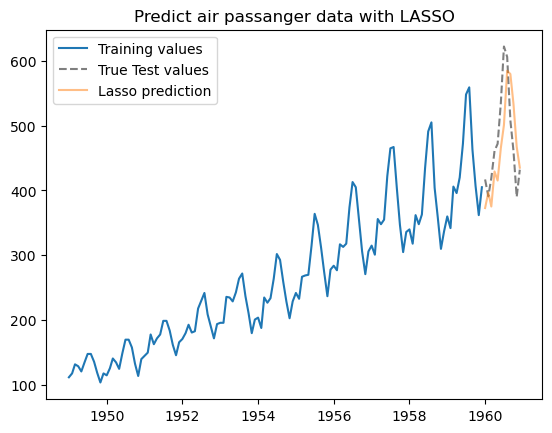

In [25]:
Lasso_rec = RecursiveForecasting(regressor = Lasso(random_state = random_state, alpha = 10), lags = 12, window_size = 20, derivative = 0)
Lasso_rec.fit(train)
Lasso_pred = Lasso_rec.forecast(steps = 12)

fig = plt.figure()
ax = fig.add_subplot()
ax.plot(train, label = "Training values")
ax.plot(test, label = "True Test values", color = "black", linestyle = "--", alpha = 0.5)
ax.plot(Lasso_pred, label = "Lasso prediction", alpha = 0.5)
ax.legend()
ax.set_title("Predict air passanger data with LASSO")
plt.show()

res_dict = add_to_resdict("LASSO", Lasso_pred, res_dict)

## RandomForestRegressor

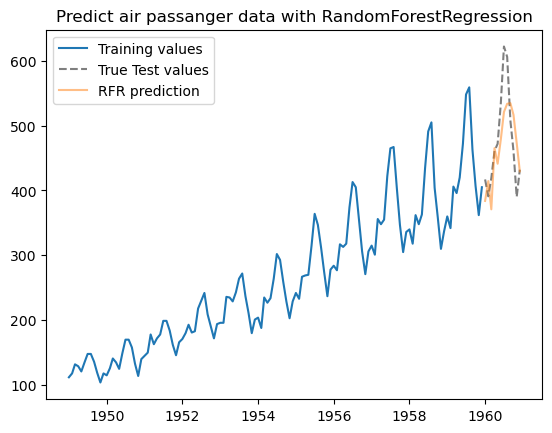

In [26]:
RFR_rec = RecursiveForecasting(regressor = RandomForestRegressor(n_estimators = 200, max_depth = 15, random_state = random_state), lags = 12, window_size = 20, derivative = 0)
RFR_rec.fit(train)
RFR_pred = RFR_rec.forecast(steps = 12)

fig = plt.figure()
ax = fig.add_subplot()
ax.plot(train, label = "Training values")
ax.plot(test, label = "True Test values", color = "black", linestyle = "--", alpha = 0.5)
ax.plot(RFR_pred, label = "RFR prediction", alpha = 0.5)
ax.legend()
ax.set_title("Predict air passanger data with RandomForestRegression")
plt.show()

res_dict = add_to_resdict("RFR", RFR_pred, res_dict)

## SupportVectorMachines

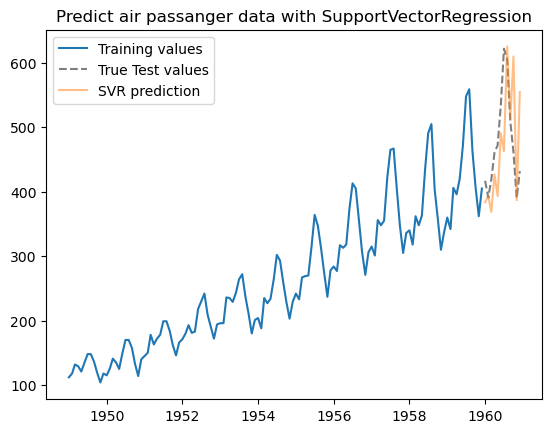

In [41]:
SVR_rec = RecursiveForecasting(regressor = SVR(kernel = "linear", C = 0.1), lags = 12, window_size = 20, derivative = 0)
SVR_rec.fit(train)
SVR_pred = SVR_rec.forecast(steps = 12)

fig = plt.figure()
ax = fig.add_subplot()
ax.plot(train, label = "Training values")
ax.plot(test, label = "True Test values", color = "black", linestyle = "--", alpha = 0.5)
ax.plot(SVR_pred, label = "SVR prediction", alpha = 0.5)
ax.legend()
ax.set_title("Predict air passanger data with SupportVectorRegression")
plt.show()

res_dict = add_to_resdict("SVR", SVR_pred, res_dict)

## GradientBoostingMachine

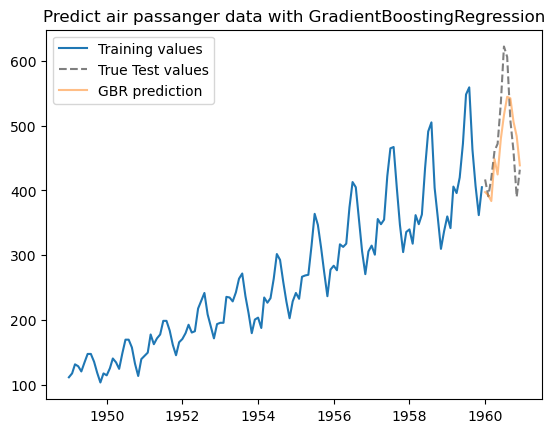

In [47]:
from sklearn.ensemble import GradientBoostingRegressor

GBR_rec = RecursiveForecasting(regressor = GradientBoostingRegressor(n_estimators = 200), lags = 12, window_size = 20, derivative = 0)
GBR_rec.fit(train)
GBR_pred = GBR_rec.forecast(steps = 12)

fig = plt.figure()
ax = fig.add_subplot()
ax.plot(train, label = "Training values")
ax.plot(test, label = "True Test values", color = "black", linestyle = "--", alpha = 0.5)
ax.plot(GBR_pred, label = "GBR prediction", alpha = 0.5)
ax.legend()
ax.set_title("Predict air passanger data with GradientBoostingRegression")
plt.show()

res_dict = add_to_resdict("GBR", GBR_pred, res_dict)

# Final Results

In [48]:
pd.DataFrame(res_dict).transpose().sort_values(by = "mse")

,mse,mae
SARIMAX,454.189229,16.701028
GBR,2844.411752,43.230991
RFR,2850.191485,44.733750
LASSO,3696.707572,51.542846
AR,3844.478604,54.908326
SVR,6327.042103,58.549674
ARIMA,10179.836329,82.286493
